### Exploratory Data Analysis

This notebook examines yield patterns, relationships between predictors and crop
yield, differences across crop types, and potential modelling concerns such as
outliers, nonlinearity, crop imbalance and multicollinearity.

The dataset used here has already been cleaned. Therefore, data cleaning,
outlier treatment and feature engineering are not repeated in this notebook.

### 1. Import libraries

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### 2. Load Raw Data

In [6]:
DATA_PATH = Path("../data/processed/crop_yield_cleaned.csv")
FIGURE_DIR = Path("reports/figures")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset Shape:", df.shape)
print(df.columns.tolist())

df.head()



Dataset loaded successfully.
Dataset Shape: (999, 8)
['rainfall', 'fertilizer', 'temperature', 'nitrogen', 'phosphorus', 'potassium', 'yield', 'crop_type']


,rainfall,fertilizer,temperature,nitrogen,phosphorus,potassium,yield,crop_type
0,1230,80,28,80,24,20,12.0,Corn
1,480,60,36,70,20,18,8.0,Sorghum
2,1250,75,29,78,22,19,11.0,Soybean
3,450,65,35,70,19,18,9.0,Sorghum
4,1200,80,27,79,22,19,11.0,Wheat


### 3. Brief data validation

In [7]:
expected_columns = [
    "crop_type",
    "rainfall",
    "temperature",
    "fertilizer",
    "nitrogen",
    "phosphorus",
    "potassium",
    "yield",
]

missing_columns = [
    column for column in expected_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

print("Missing values:")
display(df[expected_columns].isna().sum().to_frame("missing_count"))

print(f"\nDuplicate rows: {df.duplicated().sum()}")

display(df[expected_columns].describe(include="all").T)

Missing values:


,missing_count
crop_type,0
rainfall,0
temperature,0
fertilizer,0
nitrogen,0
phosphorus,0
potassium,0
yield,0



Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
crop_type,999,6,Sorghum,174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rainfall,999.0,NaN,NaN,NaN,897.567568,302.877541,400.0,619.0,905.0,1175.0,1398.0
temperature,999.0,NaN,NaN,NaN,29.582583,5.785142,20.0,25.0,29.0,34.0,40.0
fertilizer,999.0,NaN,NaN,NaN,73.837838,14.082128,50.0,61.0,74.0,85.0,99.0
nitrogen,999.0,NaN,NaN,NaN,74.483483,8.50966,59.0,67.0,75.0,82.0,89.0
phosphorus,999.0,NaN,NaN,NaN,21.816817,4.220557,15.0,18.0,22.0,26.0,29.0
potassium,999.0,NaN,NaN,NaN,16.926927,4.103577,10.0,13.0,17.0,20.0,24.0
yield,999.0,NaN,NaN,NaN,9.864464,2.804385,5.0,7.35,9.9,12.2,15.0


The raw dataset was loaded from the `data/raw` folder. A copy was created so that the original dataset remained unchanged.

The dataset was inspected to understand its dimensions, variables, data types and summary statistics before cleaning.

In [8]:
df.head(5)

,rainfall,fertilizer,temperature,nitrogen,phosphorus,potassium,yield,crop_type
0,1230,80,28,80,24,20,12.0,Corn
1,480,60,36,70,20,18,8.0,Sorghum
2,1250,75,29,78,22,19,11.0,Soybean
3,450,65,35,70,19,18,9.0,Sorghum
4,1200,80,27,79,22,19,11.0,Wheat


The cleaned dataset was checked briefly to confirm that the required variables
were present. Detailed cleaning, duplicate treatment and outlier treatment were
completed in the data-cleaning notebook and are therefore not repeated here.

## Visualizations 

### 4. Yield distribution

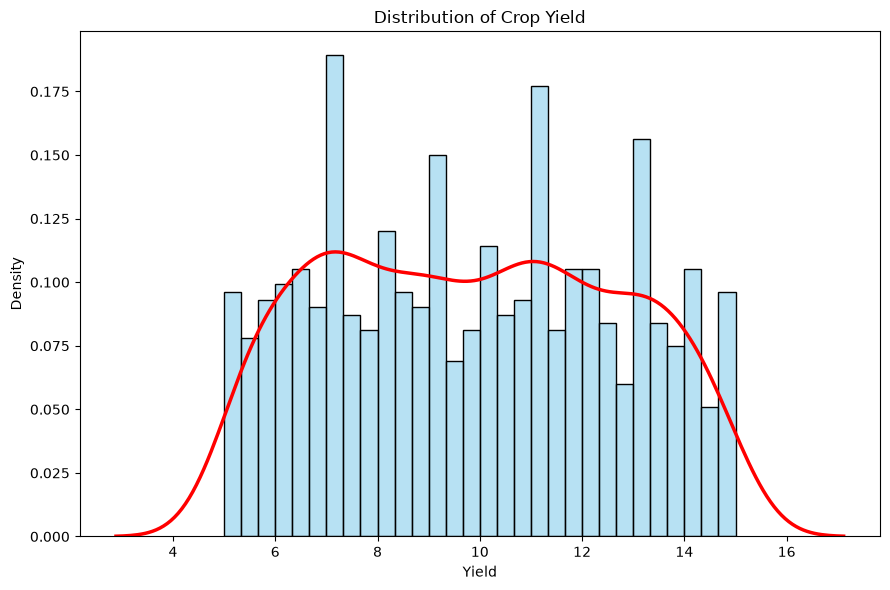

In [9]:
plt.figure(figsize=(9, 6))

sns.histplot(
    data=df,
    x="yield",
    bins=30,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=df,
    x="yield",
    color="red",
    linewidth=2.5
)

plt.title("Distribution of Crop Yield")
plt.xlabel("Yield")
plt.ylabel("Density")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "yield_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Crop yield was approximately symmetric, with no substantial skewness. However, the density curve showed several mild peaks and a relatively flat shape, suggesting that the distribution may contain subgroups or may not follow a single normal distribution.

In [10]:
yield_summary = df["yield"].describe()

print(yield_summary)
print(f"\nYield skewness: {df['yield'].skew():.3f}")

count    999.000000
mean       9.864464
std        2.804385
min        5.000000
25%        7.350000
50%        9.900000
75%       12.200000
max       15.000000
Name: yield, dtype: float64

Yield skewness: 0.059


The crop-yield variable was approximately symmetrically distributed, with a mean of 9.86 and a median of 9.90. The skewness value of 0.059 was close to zero, indicating no substantial positive or negative skew. Yield values ranged from 5.00 to 15.00, while the middle 50% of observations fell between 7.35 and 12.20. Overall, the distribution did not show evidence of severe skewness that would require transformation before modelling.

### 5. Yield box plot

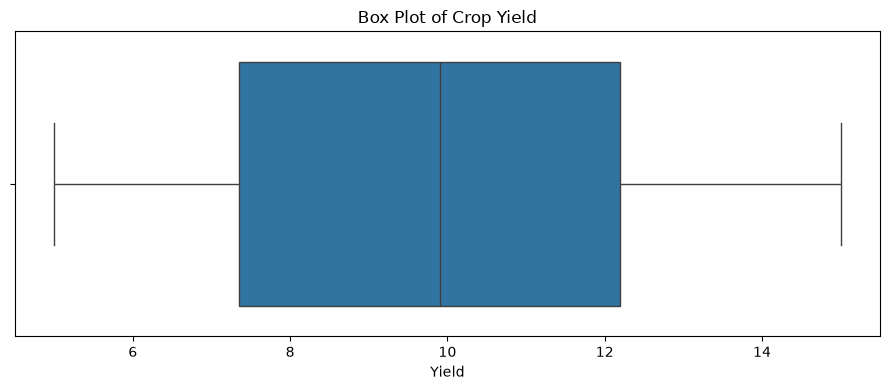

In [11]:
plt.figure(figsize=(9, 4))

sns.boxplot(
    data=df,
    x="yield"
)

plt.title("Box Plot of Crop Yield")
plt.xlabel("Yield")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "yield_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The box plot shows that crop yield is centred around a median of approximately 9.9, with the middle 50% of observations ranging from about 7.35 to 12.20. The whiskers extend from approximately 5 to 15, and no observations fall beyond them, indicating no apparent outliers based on the 1.5 × IQR rule. The relatively balanced box and whiskers also support the conclusion that the yield distribution is approximately symmetric.

In [12]:
q1 = df["yield"].quantile(0.25)
q3 = df["yield"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

potential_yield_outliers = df[
    (df["yield"] < lower_bound) |
    (df["yield"] > upper_bound)
]

print(f"Q1: {q1:.3f}")
print(f"Median: {df['yield'].median():.3f}")
print(f"Q3: {q3:.3f}")
print(f"Potential IQR outliers: {len(potential_yield_outliers)}")

Q1: 7.350
Median: 9.900
Q3: 12.200
Potential IQR outliers: 0


### 6. Yield by crop type

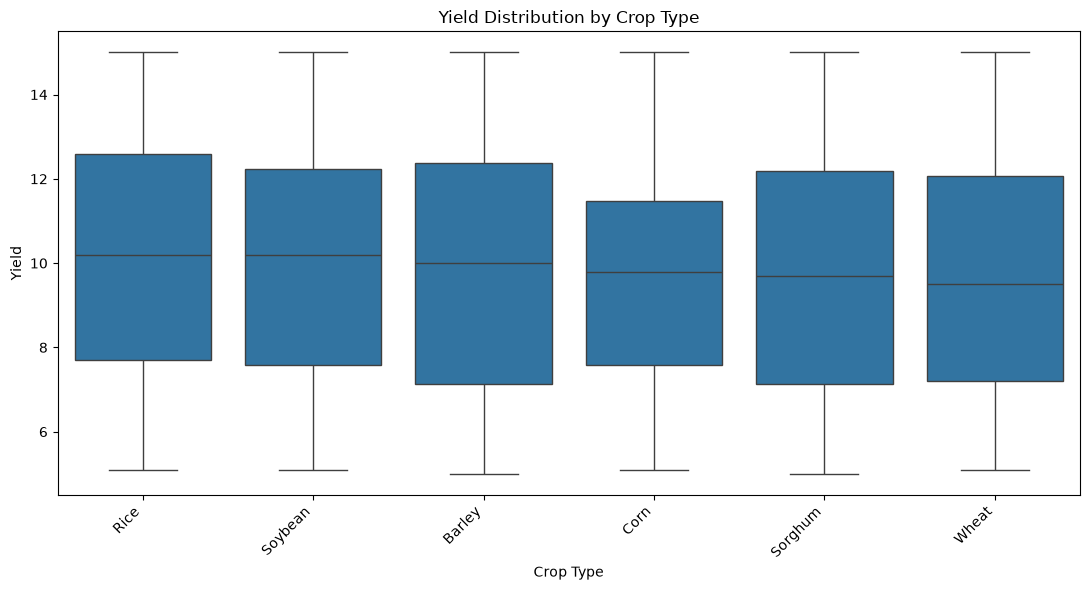

In [13]:
crop_order = (
    df.groupby("crop_type")["yield"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df,
    x="crop_type",
    y="yield",
    order=crop_order
)

plt.title("Yield Distribution by Crop Type")
plt.xlabel("Crop Type")
plt.ylabel("Yield")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "yield_by_crop_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Yield distributions were broadly similar across crop types, with substantial overlap in the interquartile ranges and overall ranges. Rice and soybean showed slightly higher median yields, while wheat, sorghum and corn had somewhat lower medians. However, the differences were relatively small compared with the within-crop variability, suggesting that crop type alone may explain only a limited proportion of yield variation.

Supporting summary:

In [14]:
crop_yield_summary = (
    df.groupby("crop_type")["yield"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        standard_deviation="std",
        minimum="min",
        maximum="max",
    )
    .sort_values("mean", ascending=False)
)

display(crop_yield_summary.round(3))

,count,mean,median,standard_deviation,minimum,maximum
crop_type,,,,,,
Rice,173,10.125,10.2,2.808,5.1,15.0
Soybean,164,9.945,10.2,2.784,5.1,15.0
Barley,170,9.938,10.0,2.855,5.0,15.0
Sorghum,174,9.775,9.7,2.877,5.0,15.0
Corn,156,9.746,9.8,2.653,5.1,15.0
Wheat,162,9.638,9.5,2.845,5.1,15.0


### 7. Crop frequency chart


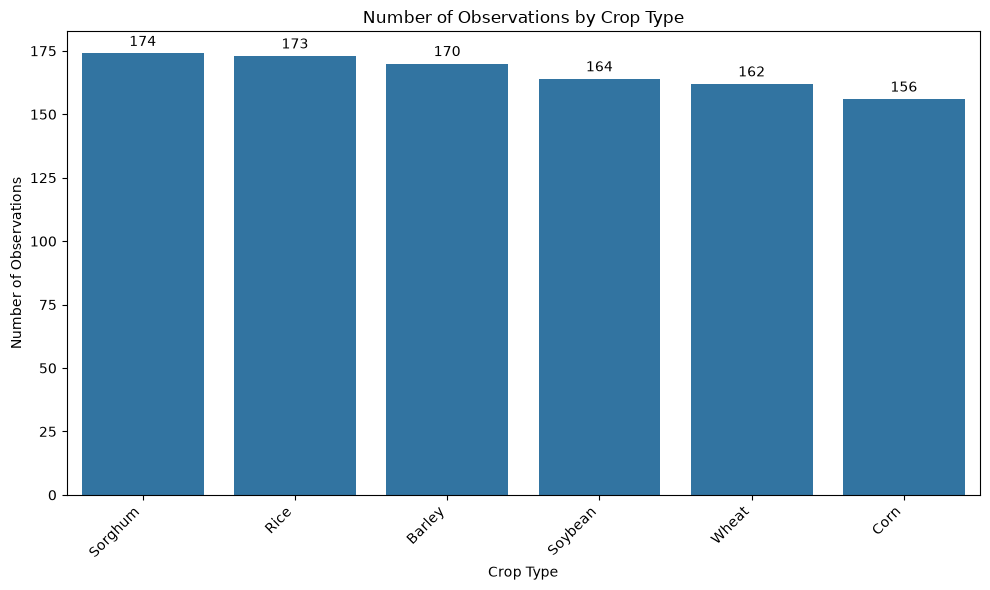

In [15]:
crop_counts = df["crop_type"].value_counts()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=crop_counts.index,
    y=crop_counts.values
)

plt.title("Number of Observations by Crop Type")
plt.xlabel("Crop Type")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "crop_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The crop-type categories were reasonably balanced, with counts ranging from 156 for corn to 174 for sorghum. No crop type was severely underrepresented, so major class imbalance was not evident. This balance is useful for comparing yield distributions across crops and reduces the risk that the model will be dominated by one crop category.

Check imbalance numerically:

In [16]:
crop_frequency_table = (
    df["crop_type"]
    .value_counts()
    .rename_axis("crop_type")
    .reset_index(name="count")
)

crop_frequency_table["percentage"] = (
    100 * crop_frequency_table["count"] / len(df)
)

display(crop_frequency_table.round(2))

,crop_type,count,percentage
0,Sorghum,174,17.42
1,Rice,173,17.32
2,Barley,170,17.02
3,Soybean,164,16.42
4,Wheat,162,16.22
5,Corn,156,15.62


## Predictor relationships with yield
Use the same format for each numerical predictor. A regression line helps show the overall linear direction, but the scatter should also be inspected for curvature and uneven spread.

### 8. Reusable scatter-plot function

In [17]:
def plot_predictor_vs_yield(
    data,
    predictor,
    title,
    xlabel,
    filename,
):
    """
    Create and save a scatter plot with a fitted linear trend line.
    """
    plt.figure(figsize=(9, 6))

    sns.regplot(
        data=data,
        x=predictor,
        y="yield",
        scatter_kws={
            "alpha": 0.45,
            "s": 35,
        },
        line_kws={"color": "red",
            "linewidth": 2,
        },
        ci=95,
    )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Yield")
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### 9. Rainfall versus yield

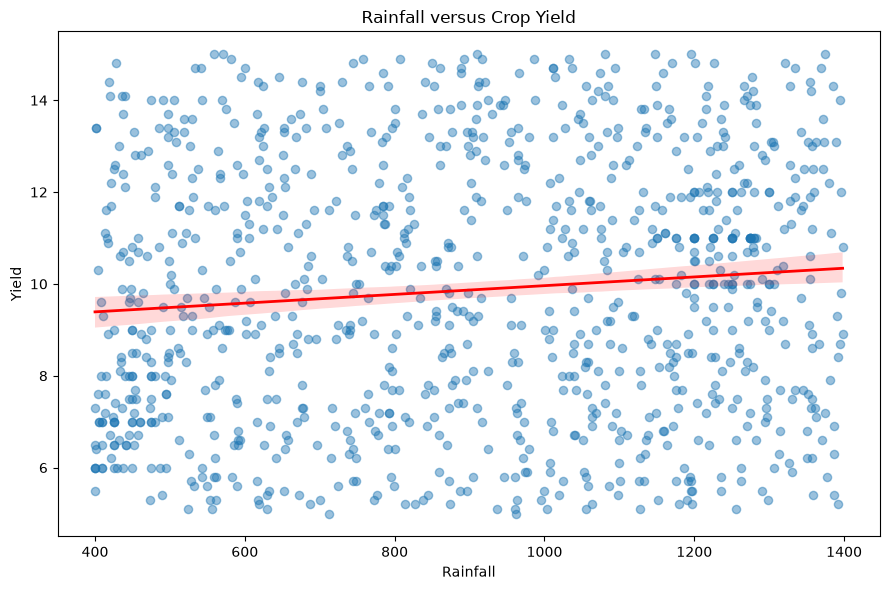

In [18]:
plot_predictor_vs_yield(
    data=df,
    predictor="rainfall",
    title="Rainfall versus Crop Yield",
    xlabel="Rainfall",
    filename="rainfall_vs_yield.png",
)

Rainfall showed a weak positive association with crop yield. Although the fitted trend line increased slightly as rainfall rose, the wide dispersion of observations around the line indicates that rainfall alone has limited explanatory power. The relationship also appears weak enough that other variables, interactions or unobserved factors are likely to play a larger role in determining yield.

### 10. Temperature versus yield

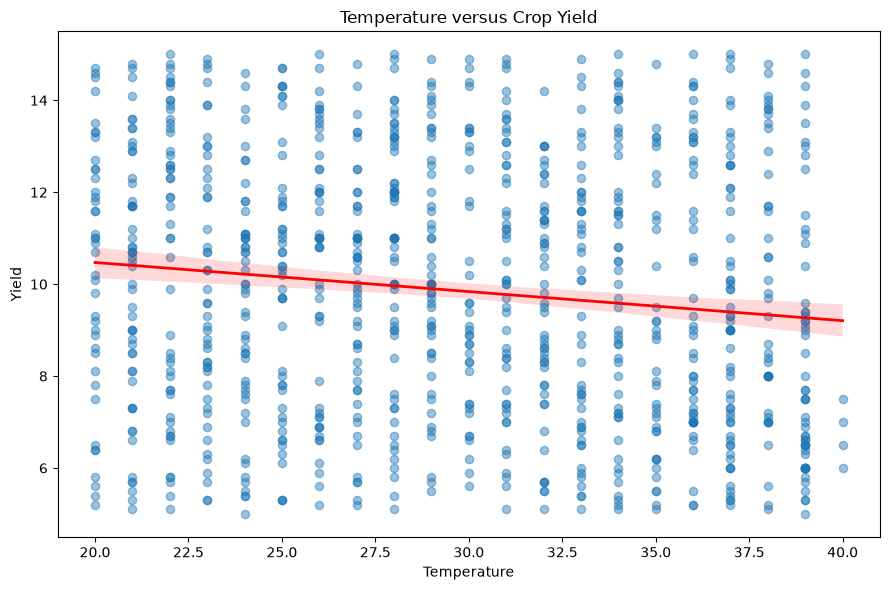

In [19]:
plot_predictor_vs_yield(
    data=df,
    predictor="temperature",
    title="Temperature versus Crop Yield",
    xlabel="Temperature",
    filename="temperature_vs_yield.png",
)

Temperature showed a weak negative association with crop yield. The fitted trend line declined gradually as temperature increased, suggesting slightly lower yields at higher temperatures. However, the wide spread of observations around the line indicates that temperature alone has limited explanatory power and that other variables or interactions are likely to influence yield.

### 11. Fertiliser versus yield

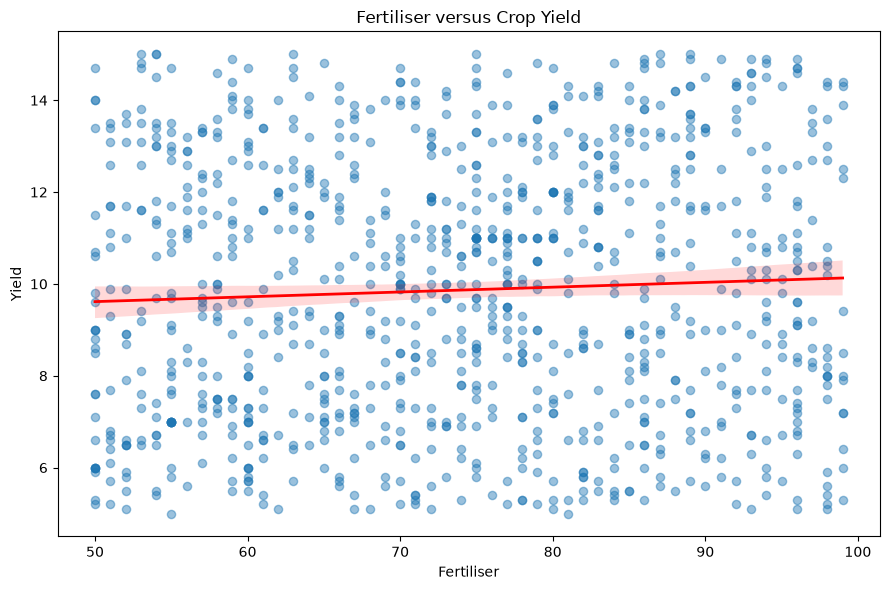

In [20]:
plot_predictor_vs_yield(
    data=df,
    predictor="fertilizer",
    title="Fertiliser versus Crop Yield",
    xlabel="Fertiliser",
    filename="fertilizer_vs_yield.png",
)

Fertiliser showed a weak positive association with crop yield. Although the fitted trend line increased slightly as fertiliser levels rose, the wide dispersion of observations indicates that fertiliser alone has limited explanatory power. The pattern suggests that fertiliser effects may depend on other conditions, such as rainfall or nutrient balance, rather than operating independently.

### 12. Nitrogen versus yield

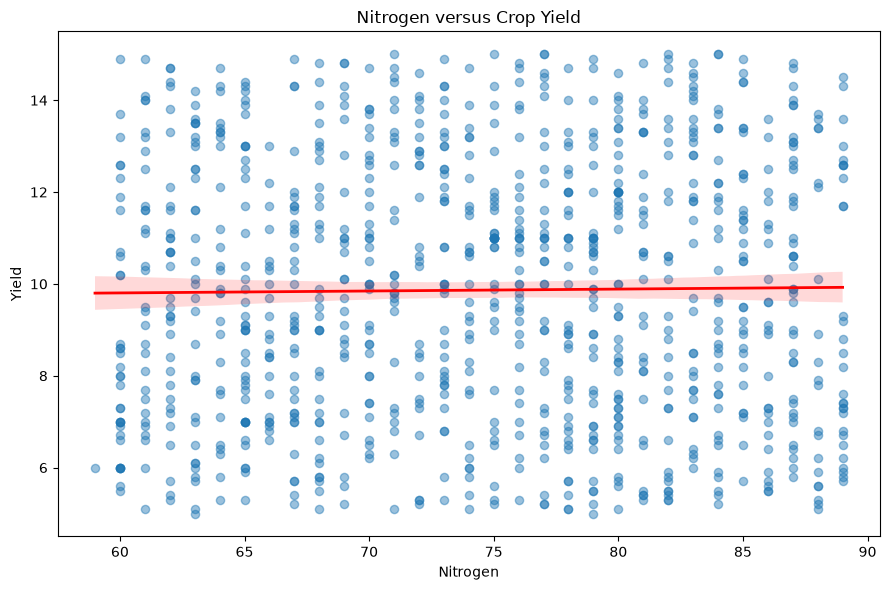

In [21]:
plot_predictor_vs_yield(
    data=df,
    predictor="nitrogen",
    title="Nitrogen versus Crop Yield",
    xlabel="Nitrogen",
    filename="nitrogen_vs_yield.png",
)

Nitrogen showed a negligible positive association with crop yield. The broad scatter around the fitted line suggests that nitrogen alone has very limited explanatory power.

### 13. Phosphorus versus yield

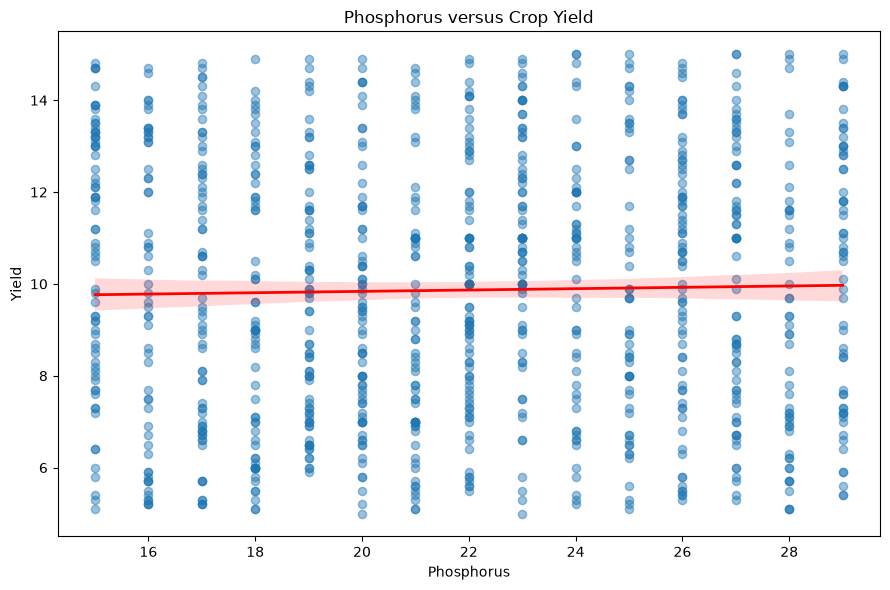

In [22]:
plot_predictor_vs_yield(
    data=df,
    predictor="phosphorus",
    title="Phosphorus versus Crop Yield",
    xlabel="Phosphorus",
    filename="phosphorus_vs_yield.png",
)

Phosphorus showed a very weak positive association with crop yield. The wide spread of observations indicates that phosphorus alone explains little of the variation in yield.

### 14. Potassium versus yield

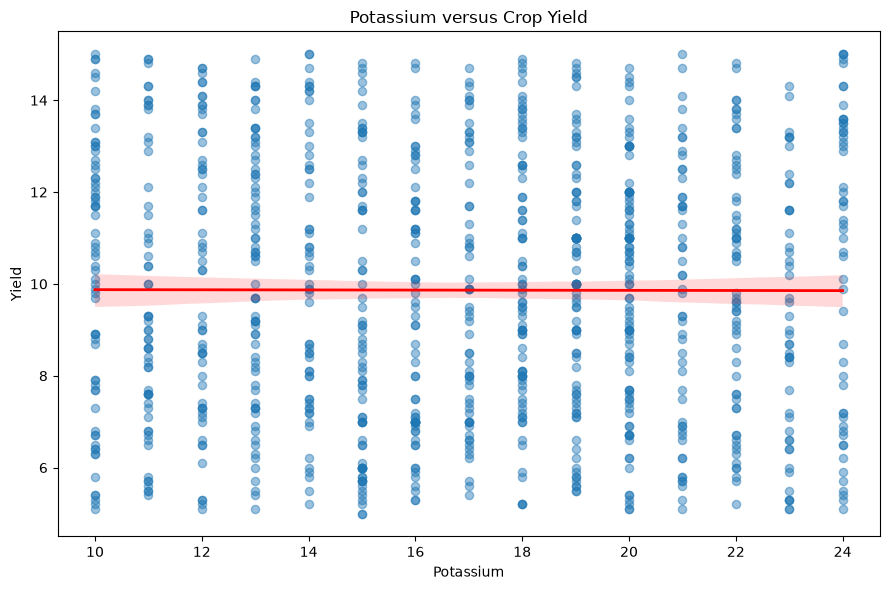

In [23]:
plot_predictor_vs_yield(
    data=df,
    predictor="potassium",
    title="Potassium versus Crop Yield",
    xlabel="Potassium",
    filename="potassium_vs_yield.png",
)

Potassium showed little to no clear association with crop yield. Its standalone contribution appears negligible based on the visual pattern.

### 15. Correlations with yield


In [24]:
numerical_columns = [
    "rainfall",
    "temperature",
    "fertilizer",
    "nitrogen",
    "phosphorus",
    "potassium",
    "yield",
]

yield_correlations = (
    df[numerical_columns]
    .corr()["yield"]
    .drop("yield")
    .sort_values(key=abs, ascending=False)
    .to_frame("correlation_with_yield")
)

display(yield_correlations.round(3))

,correlation_with_yield
temperature,-0.131
rainfall,0.103
fertilizer,0.053
phosphorus,0.022
nitrogen,0.013
potassium,-0.002


### Correlation and multicollinearity

### 16. Correlation heatmap

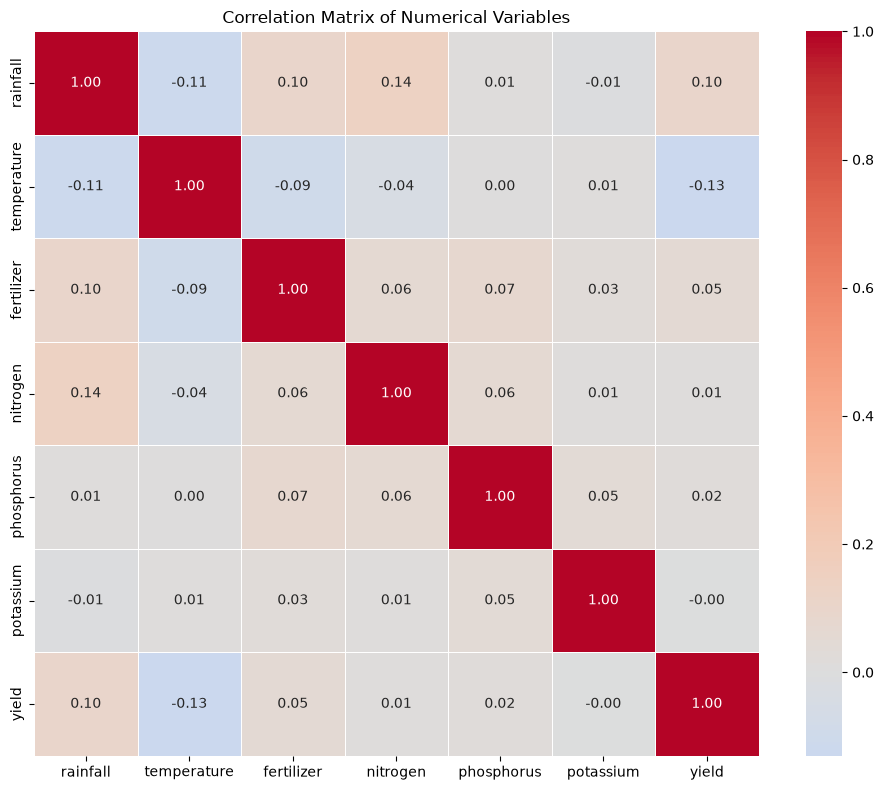

In [25]:
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The correlation matrix showed generally weak relationships between the numerical predictors and crop yield. Temperature had the strongest association with yield, with a weak negative correlation of approximately −0.13, while rainfall had a weak positive correlation of approximately 0.10. Fertiliser and the individual NPK variables showed negligible correlations with yield. Correlations among the predictors were also low, indicating no evidence of serious pairwise multicollinearity in the original feature set.

Identify large predictor-predictor correlations:

In [26]:
predictor_columns = [
    "rainfall",
    "temperature",
    "fertilizer",
    "nitrogen",
    "phosphorus",
    "potassium",
]

predictor_correlations = df[predictor_columns].corr().abs()

upper_triangle = predictor_correlations.where(
    pd.DataFrame(
        [
            [column_index > row_index for column_index in range(len(predictor_columns))]
            for row_index in range(len(predictor_columns))
        ],
        index=predictor_columns,
        columns=predictor_columns,
    )
)

high_correlation_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_correlation_pairs.columns = [
    "feature_1",
    "feature_2",
    "absolute_correlation",
]

high_correlation_pairs = high_correlation_pairs.sort_values(
    "absolute_correlation",
    ascending=False
)

display(high_correlation_pairs.head(10).round(3))

,feature_1,feature_2,absolute_correlation
3,rainfall,nitrogen,0.139
1,rainfall,temperature,0.114
2,rainfall,fertilizer,0.102
8,temperature,fertilizer,0.091
16,fertilizer,phosphorus,0.073
15,fertilizer,nitrogen,0.063
22,nitrogen,phosphorus,0.059
29,phosphorus,potassium,0.047
9,temperature,nitrogen,0.044
17,fertilizer,potassium,0.025


### Numerical feature box plots

### 17. Separate numerical box plots

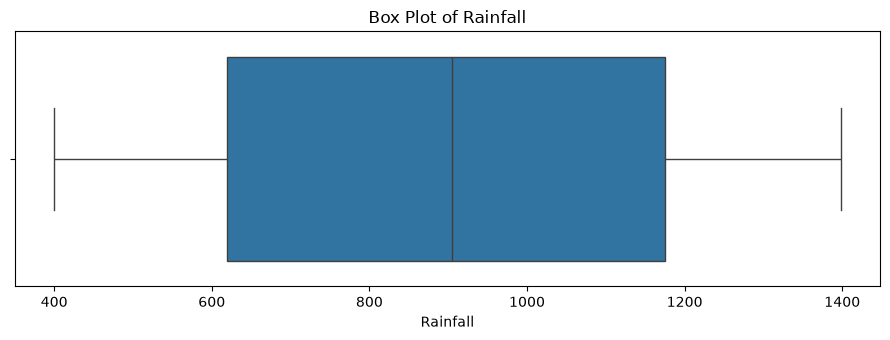

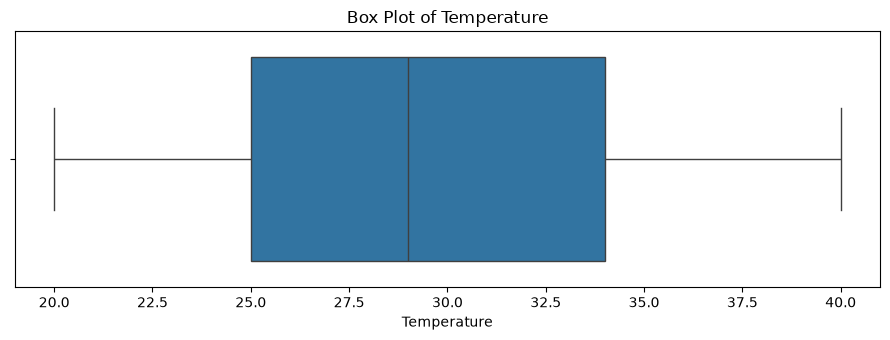

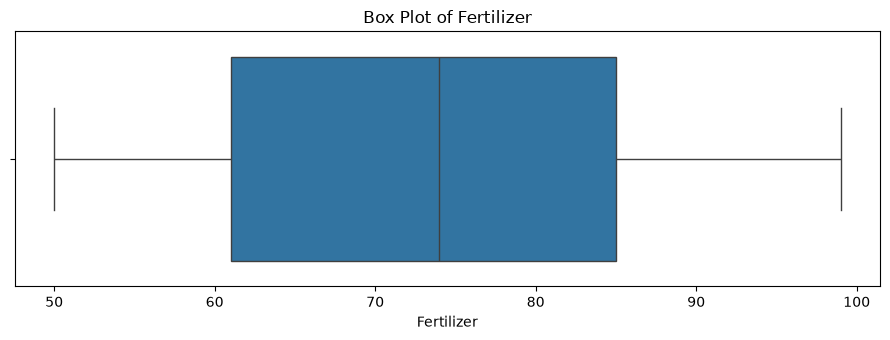

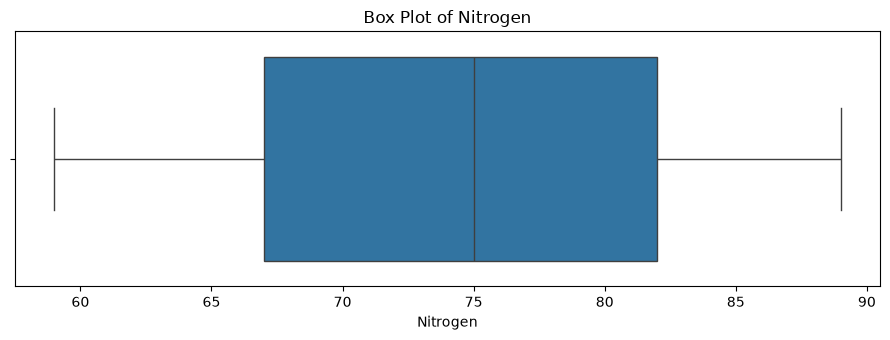

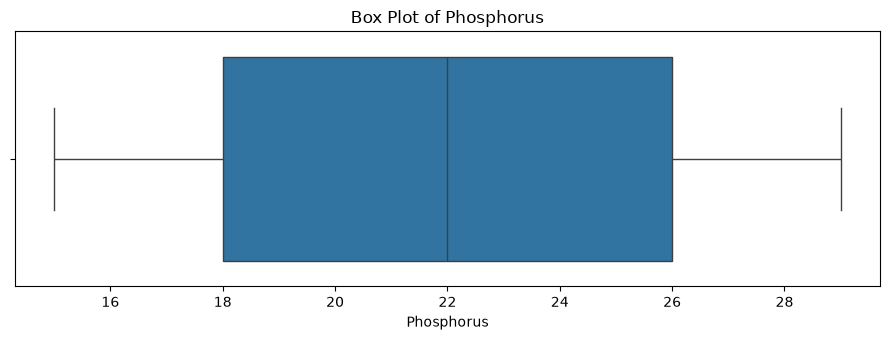

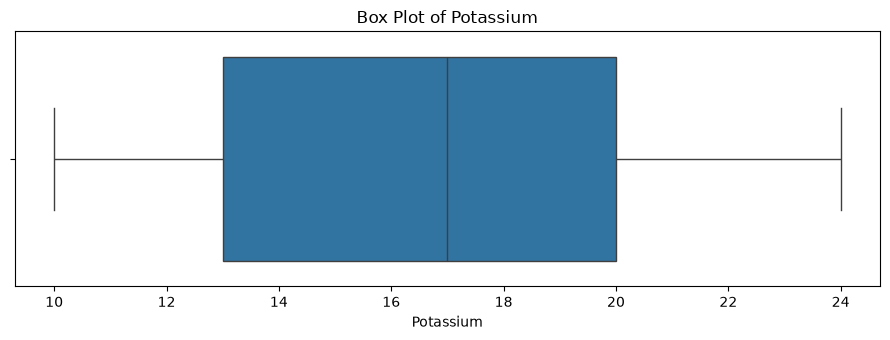

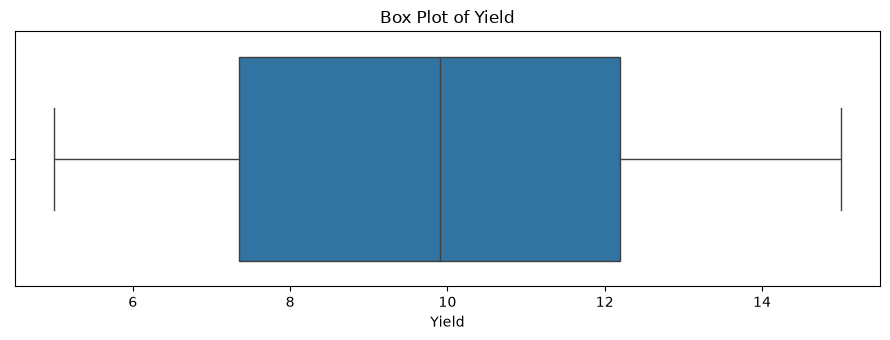

In [27]:
boxplot_columns = [
    "rainfall",
    "temperature",
    "fertilizer",
    "nitrogen",
    "phosphorus",
    "potassium",
    "yield",
]

for column in boxplot_columns:
    plt.figure(figsize=(9, 3.5))

    sns.boxplot(
        data=df,
        x=column
    )

    plt.title(f"Box Plot of {column.replace('_', ' ').title()}")
    plt.xlabel(column.replace("_", " ").title())
    plt.tight_layout()

    output_name = f"{column}_boxplot.png"

    plt.savefig(
        FIGURE_DIR / output_name,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

The numerical box plots showed no apparent extreme outliers across rainfall, temperature, fertiliser, nitrogen, phosphorus, potassium and yield. The distributions were generally balanced, with medians positioned near the centres of their respective interquartile ranges. These findings suggest that no additional outlier treatment is required at the EDA stage.

Create an outlier summary without altering the data:

In [28]:
outlier_summary = []

for column in boxplot_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_summary.append({
        "feature": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "potential_outliers": outlier_count,
        "percentage": 100 * outlier_count / len(df),
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

display(outlier_summary_df.round(3))

,feature,lower_bound,upper_bound,potential_outliers,percentage
0,rainfall,-215.000,2009.000,0,0.0
1,temperature,11.500,47.500,0,0.0
2,fertilizer,25.000,121.000,0,0.0
3,nitrogen,44.500,104.500,0,0.0
4,phosphorus,6.000,38.000,0,0.0
5,potassium,2.500,30.500,0,0.0
6,yield,0.075,19.475,0,0.0


### EDA summary

### 18. Automated summary values

In [29]:
eda_summary = {
    "number_of_observations": len(df),
    "number_of_crop_types": df["crop_type"].nunique(),
    "mean_yield": df["yield"].mean(),
    "median_yield": df["yield"].median(),
    "yield_standard_deviation": df["yield"].std(),
    "yield_skewness": df["yield"].skew(),
    "most_common_crop": df["crop_type"].mode().iloc[0],
    "least_common_crop": df["crop_type"].value_counts().idxmin(),
}

pd.Series(eda_summary).to_frame("value")

,value
number_of_observations,999
number_of_crop_types,6
mean_yield,9.864464
median_yield,9.9
yield_standard_deviation,2.804385
yield_skewness,0.058833
most_common_crop,Sorghum
least_common_crop,Corn


### Statistical tests

### 1. Levene’s test to check equality of variances:

In [30]:
from scipy.stats import levene

crop_groups = [
    group["yield"].values
    for _, group in df.groupby("crop_type")
]

levene_stat, levene_p = levene(
    *crop_groups,
    center="median"
)

print(f"Levene statistic: {levene_stat:.4f}")
print(f"Levene p-value: {levene_p:.4f}")

Levene statistic: 0.7264
Levene p-value: 0.6037


Since p>0.05, there is no evidence that yield variances differ across crop types. The equal-variance assumption is therefore reasonable.

### One-way ANOVA to check equality of mean yield across crop types

In [31]:
from scipy.stats import f_oneway

crop_groups = [
    group["yield"].values
    for _, group in df.groupby("crop_type")
]

anova_stat, anova_p = f_oneway(*crop_groups)

print(f"ANOVA F-statistic: {anova_stat:.4f}")
print(f"ANOVA p-value: {anova_p:.4f}")

ANOVA F-statistic: 0.6494
ANOVA p-value: 0.6621


A one-way ANOVA was conducted to examine whether mean yield differed across crop types. The result was not statistically significant, F(5,993)=0.6494, p=0.6621. Therefore, there was no evidence of a difference in mean yield among rice, soybean, barley, corn, sorghum and wheat. This suggests that crop type alone provides limited information for explaining yield variation in the dataset.

In [32]:
grand_mean = df["yield"].mean()

ss_between = sum(
    len(group) * (group["yield"].mean() - grand_mean) ** 2
    for _, group in df.groupby("crop_type")
)

ss_total = ((df["yield"] - grand_mean) ** 2).sum()

eta_squared = ss_between / ss_total

print(f"Eta-squared: {eta_squared:.4f}")

Eta-squared: 0.0033


Levene’s test showed that yield variances were similar across crop types, F=0.7264, p=0.6037. A one-way ANOVA subsequently found no significant difference in mean yield across crop types, F(5,993)=0.6494, p=0.6621. The effect size was negligible, η
2
=0.0033, indicating that crop type explained only approximately 0.33% of the total variation in yield

### 2. Correlation Analysis Between Rainfall and Crop Yield

In [33]:
from scipy.stats import pearsonr, spearmanr

pearson_r, pearson_p = pearsonr(
    df["rainfall"],
    df["yield"]
)

spearman_r, spearman_p = spearmanr(
    df["rainfall"],
    df["yield"]
)

print(f"Pearson r: {pearson_r:.4f}")
print(f"Pearson p-value: {pearson_p:.4f}")

print(f"Spearman rho: {spearman_r:.4f}")
print(f"Spearman p-value: {spearman_p:.4f}")

Pearson r: 0.1027
Pearson p-value: 0.0012
Spearman rho: 0.1065
Spearman p-value: 0.0007


Pearson’s correlation showed a weak positive linear relationship between rainfall and crop yield, r=0.1027, p=0.0012. Spearman’s rank correlation produced a similar result, ρ=0.1065, p=0.0007, indicating a weak positive monotonic association. Although both relationships were statistically significant, their magnitudes were small, suggesting that rainfall alone explains very little of the variation in crop yield.

### 3. Correlation Analysis Between Temperature and Crop Yield

In [34]:
from scipy.stats import pearsonr, spearmanr

pearson_r, pearson_p = pearsonr(
    df["temperature"],
    df["yield"]
)

spearman_r, spearman_p = spearmanr(
    df["temperature"],
    df["yield"]
)

print(f"Pearson r: {pearson_r:.4f}")
print(f"Pearson p-value: {pearson_p:.4f}")

print(f"Spearman rho: {spearman_r:.4f}")
print(f"Spearman p-value: {spearman_p:.4f}")

Pearson r: -0.1306
Pearson p-value: 0.0000
Spearman rho: -0.1309
Spearman p-value: 0.0000


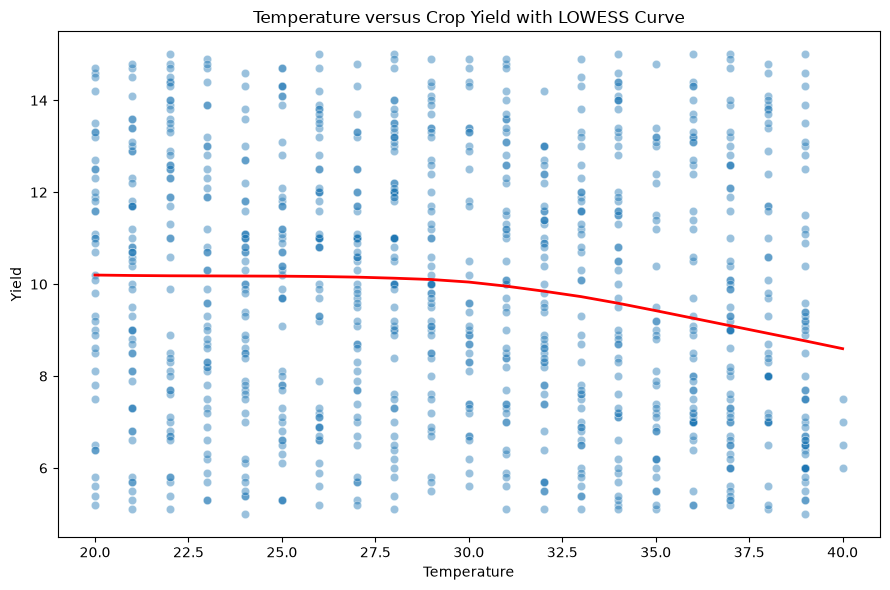

In [35]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="temperature",
    y="yield",
    alpha=0.45
)

sns.regplot(
    data=df,
    x="temperature",
    y="yield",
    scatter=False,
    lowess=True,
    color="red",
    line_kws={"linewidth": 2}
)

plt.title("Temperature versus Crop Yield with LOWESS Curve")
plt.xlabel("Temperature")
plt.ylabel("Yield")
plt.tight_layout()
plt.show()

In [39]:
import statsmodels.formula.api as smf

linear_temp_model = smf.ols(
    'Q("yield") ~ temperature',
    data=df
).fit()

quadratic_temp_model = smf.ols(
    'Q("yield") ~ temperature + I(temperature ** 2)',
    data=df
).fit()

print("Linear model")
print(f"R-squared: {linear_temp_model.rsquared:.4f}")
print(f"AIC: {linear_temp_model.aic:.2f}")

print("\nQuadratic model")
print(f"R-squared: {quadratic_temp_model.rsquared:.4f}")
print(f"AIC: {quadratic_temp_model.aic:.2f}")

print("\nQuadratic-term p-value:")
print(quadratic_temp_model.pvalues["I(temperature ** 2)"])

Linear model
R-squared: 0.0171
AIC: 4881.16

Quadratic model
R-squared: 0.0225
AIC: 4877.57

Quadratic-term p-value:
0.018250061218277307


Temperature showed a weak negative association with crop yield, with the LOWESS curve indicating a mild downward curvature at higher temperatures. A quadratic model fitted slightly better than a simple linear model, with R
2
 increasing from 0.0171 to 0.0225 and AIC decreasing from 4881.16 to 4877.57. The squared temperature term was statistically significant, p=0.0183. This suggests that nonlinear temperature effects may be considered during subsequent feature engineering, although temperature alone explains only a small proportion of yield variation.

### 3. Correlation Analysis Between Fertiliser and Crop Yield

In [40]:
from scipy.stats import pearsonr, spearmanr

pearson_r, pearson_p = pearsonr(
    df["fertilizer"],
    df["yield"]
)

spearman_r, spearman_p = spearmanr(
    df["fertilizer"],
    df["yield"]
)

print(f"Pearson r: {pearson_r:.4f}")
print(f"Pearson p-value: {pearson_p:.4f}")

print(f"Spearman rho: {spearman_r:.4f}")
print(f"Spearman p-value: {spearman_p:.4f}")

Pearson r: 0.0527
Pearson p-value: 0.0960
Spearman rho: 0.0530
Spearman p-value: 0.0944


Fertiliser showed a very weak positive relationship with crop yield. Pearson’s correlation was r=0.0527, p=0.0960, while Spearman’s rank correlation was ρ=0.0530, p=0.0944. Since both p-values exceeded 0.05, the associations were not statistically significant. This suggests that fertiliser alone has little direct explanatory power for yield in the dataset.

### For the EDA implication:

The weak standalone relationship suggests that fertiliser may be more informative when considered jointly with other variables, such as rainfall, rather than as an isolated predictor.

### 4. Correlation Analysis Between NPK Nutrients and Crop Yield

In [42]:
from scipy.stats import pearsonr, spearmanr

nutrients = ["nitrogen", "phosphorus", "potassium"]

for nutrient in nutrients:
    pearson_r, pearson_p = pearsonr(df[nutrient], df["yield"])
    spearman_r, spearman_p = spearmanr(df[nutrient], df["yield"])

    print(f"\n{nutrient.title()} versus Yield")
    print(f"Pearson r: {pearson_r:.4f}")
    print(f"Pearson p-value: {pearson_p:.4f}")
    print(f"Spearman rho: {spearman_r:.4f}")
    print(f"Spearman p-value: {spearman_p:.4f}")


Nitrogen versus Yield
Pearson r: 0.0127
Pearson p-value: 0.6884
Spearman rho: 0.0112
Spearman p-value: 0.7247

Phosphorus versus Yield
Pearson r: 0.0221
Pearson p-value: 0.4858
Spearman rho: 0.0244
Spearman p-value: 0.4419

Potassium versus Yield
Pearson r: -0.0022
Pearson p-value: 0.9441
Spearman rho: -0.0006
Spearman p-value: 0.9842


Nitrogen, phosphorus and potassium each showed negligible standalone associations with crop yield. Pearson and Spearman correlation coefficients were all close to zero and statistically non-significant. This indicates that none of the individual nutrient variables explained meaningful variation in yield when considered in isolation.